# LBM Lid-Driven Cavity Simulation Assessment
**File:** `analysis_100x100.ipynb`  
**Author:** Marcel Wilanowicz  
**Date:** 2026-06-10  

---

### Description:
This notebook provides a comprehensive assessment of the Lattice Boltzmann Method (LBM) simulation for the Lid-Driven Cavity problem. It consists of three stages:


1. **Physical Validation:** Comparison of normalized centerline velocity profiles ($u_x, u_y$) against the established benchmark data by Ghia et al. (1982).

2. **Parallel Verification:** A spatial node-by-node identity check between the sequential and MPI parallel versions to ensure bitwise reproducibility and correct domain decomposition.

3. **Scaling Benchmark:** Measurement of elapsed time, speedup, and efficiency of parallelization as a function of MPI process count to evaluate the overhead and scalability of the implementation. 

## 1. Physical Validation: Comparison with Ghia et al. (1982)

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import os

# Config
H = 100
W = 100
U_LID = 0.1

GRID = f"{W}x{H}"

In [102]:
# Results for u-velocity along Vertical Line through Geometric Center of Cavity 
# [Ghia et al. p.398, Table I]
ghia_y =  [0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813, 0.4531, 
           0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]

ghia_ux = [0.00000, -0.03717, -0.04192, -0.04775, -0.06434, -0.10150, -0.15662, -0.21090, 
           -0.20581, -0.14098, -0.01447, 0.17527, 0.55892, 0.61756, 0.68439, 0.75837, 1.00000]

# Results for u-velocity along Vertical Line through Geometric Center of Cavity 
#[Ghia et al. p.399, Table II]
ghia_x = [0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344, 0.5000, 
          0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]

ghia_uy = [0.00000, 0.09233, 0.10091, 0.10890, 0.12317, 0.16077, 0.17507, 0.17527, 
           0.05454, -0.24533, -0.22445, -0.16914, -0.10313, -0.08864, -0.07391, -0.05906, 0.00000]


In [103]:
def get_output_by_suffix(suffix=""):
    """
    Finds CSV output file for given grid size and suffix (e.g. '_mpi_4_halo_on').
    """
    base_dir = f"../outputs/{GRID}"
    if not os.path.exists(base_dir):
        print(f"Error: Directory '{base_dir}' not found")
        return None
    
    for file_name in os.listdir(base_dir):
        if file_name.endswith(".csv") and "benchmark" not in file_name:
            if suffix == "" or suffix in file_name:
                return os.path.join(base_dir, file_name)
    
    print(f"Error: No file found with suffix '{suffix}'")
    return None

In [104]:
def validate(suffix=""):
    target_file = get_output_by_suffix(suffix=suffix)

    if not target_file:
        print("Error: Not found any files in 'outputs' directory.")
        return
    
    print(f"Loading data from: {target_file}")
    data = pd.read_csv(target_file)

    # Centerline grid coordinates
    mid_x = (W - 1) // 2
    mid_y = (H - 1) // 2

    # Extracting vertical profile for ux comparison
    v_line = data[data['x'] == mid_x].sort_values('y')

    # Extracting horizontal profile for uy comparison
    h_line = data[data['y'] == mid_y].sort_values('x')

    # Normalizing the data (velocity profiles and dimension of the grid): 
    # we want dimensionless values for correct benchmark [Chen & Doolen, 1998, p.342].
    ux_norm = v_line['ux'] / U_LID
    y_norm = v_line['y'] / (H - 1)
    uy_norm = h_line['uy'] / U_LID
    x_norm = h_line['x'] / (W - 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # ------------ 1. Plotting vertical profile: ux(y) ------------

    # Simulation data
    ax1.plot(ux_norm, y_norm, 'b-', label='LBM Simulation Data', linewidth=2)

    # Ghia data
    ax1.plot(ghia_ux, ghia_y, 'ro', label='Ghia et al. (1982) Reference', markersize=6)

    ax1.set_title(f"Vertical Profile $u_x$ (Step: 10000)")
    ax1.set_xlabel("$u_x / u_{lid}$")
    ax1.set_ylabel("$y / H$")
    ax1.set_xlim([-1.0, 1.0])
    ax1.set_ylim([-0.1, 1.1])
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)
    ax1.legend()

    # ------------ 2. Plotting horizontal profile: uy(x) ------------

    # LBM data
    ax2.plot(uy_norm, x_norm, 'b-', label='LBM Simulation Data', linewidth=2)

    # Ghia data
    ax2.plot(ghia_uy, ghia_x, 'ro', label='Ghia et al. (1982) Reference', markersize=6)

    ax2.set_title(f"Horizontal Profile $u_y$ (Step: 10000)")
    ax2.set_xlabel("$u_y / u_{lid}$")
    ax2.set_ylabel("$x / W$")
    ax2.set_xlim([-1.0, 1.0])
    ax2.set_ylim([-0.1, 1.1])
    ax2.grid(True, which='both', linestyle='--', alpha=0.5)
    ax2.legend()

    # Extract MPI process count directly from the par_file path string
    match = re.search(r"_mpi_(\d+)", target_file)
    if match:
        num_procs = match.group(1)
    else:
        num_procs = "1 (Sequential)"

    plt.suptitle(f"LBM Velocity Profiles Validation vs Ghia et al. Reference (Step: 10000, MPI Procs: {num_procs})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

### 1.1 Sequential

Loading data from: ../outputs/100x100/output_100x100_mpi_1_halo_off.csv


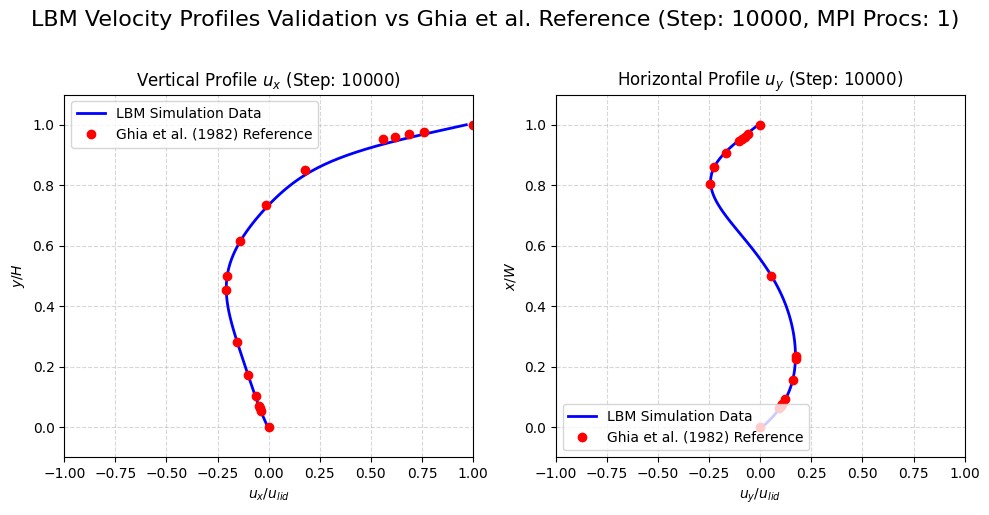

In [105]:
validate("_mpi_1_halo_off")

### 1.2 Decomposition without HALO

Loading data from: ../outputs/100x100/output_100x100_mpi_2_halo_off.csv


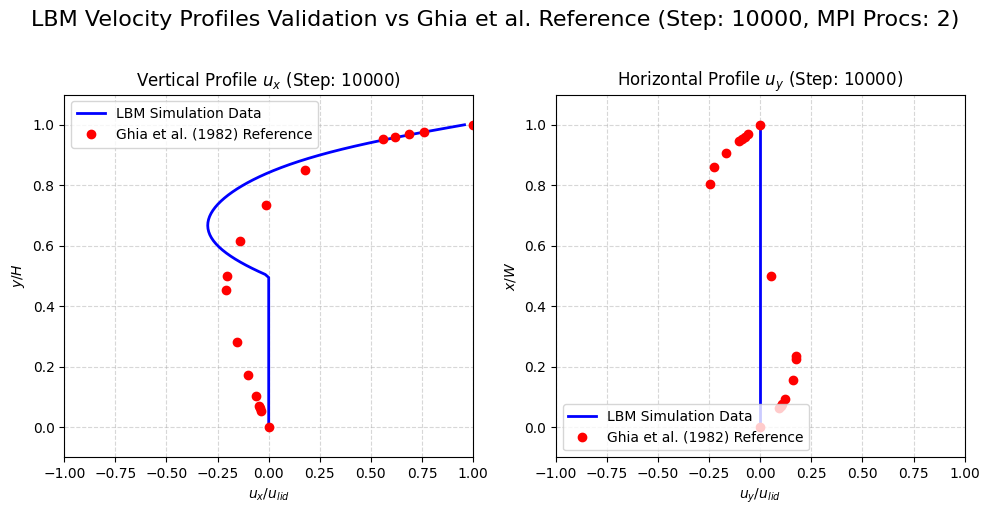

In [106]:
validate("_mpi_2_halo_off")

Loading data from: ../outputs/100x100/output_100x100_mpi_4_halo_off.csv


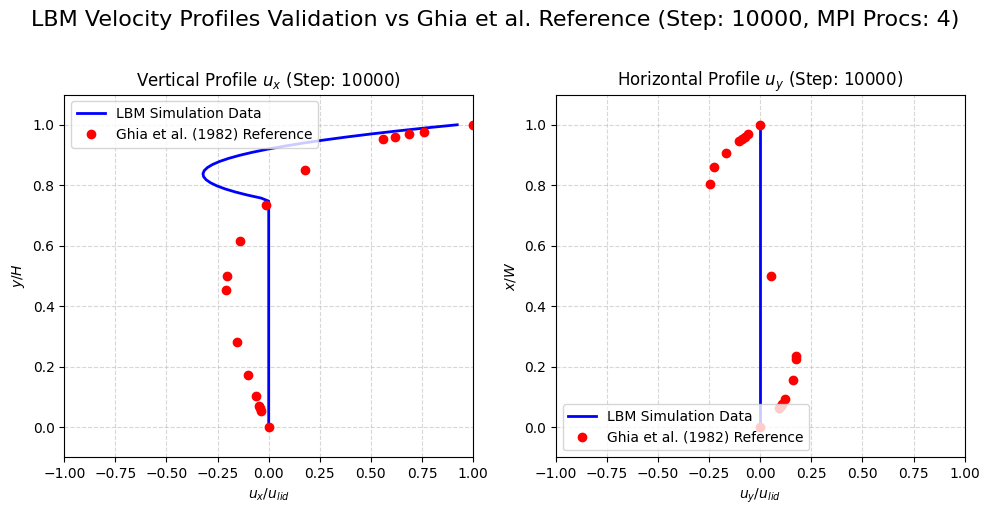

In [107]:
validate("_mpi_4_halo_off")

### 1.3 Decomposition with HALO

Loading data from: ../outputs/100x100/output_100x100_mpi_2_halo_on.csv


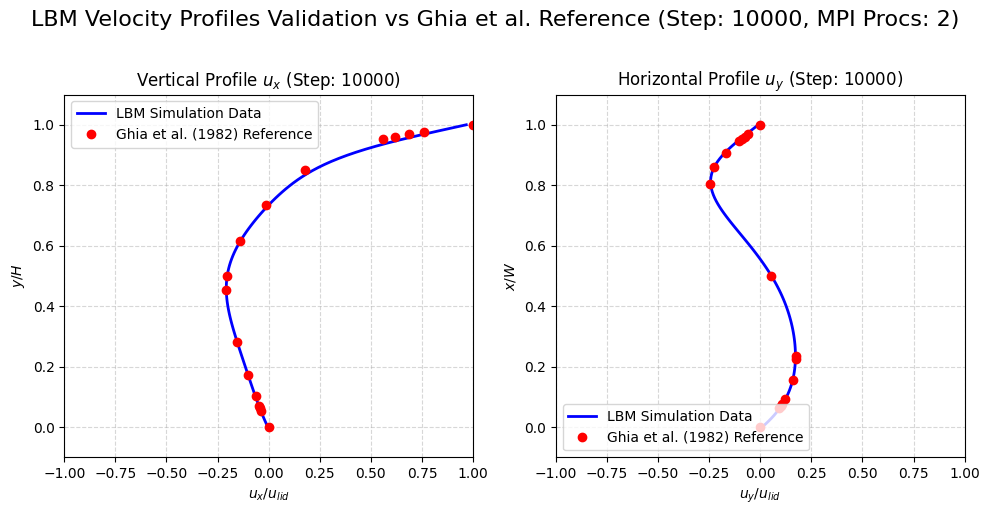

In [108]:
validate("_mpi_2_halo_on")

Loading data from: ../outputs/100x100/output_100x100_mpi_4_halo_on.csv


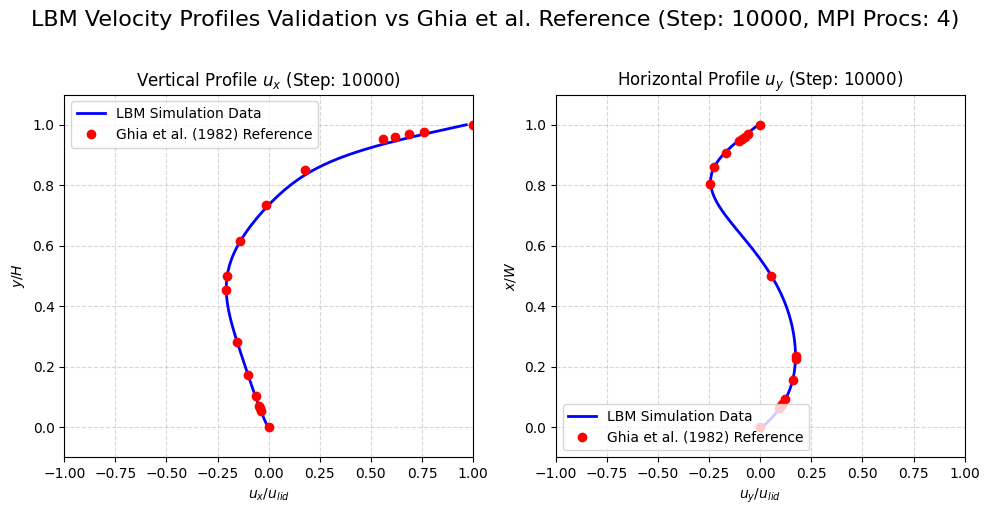

In [109]:
validate("_mpi_4_halo_on")

## 2. Parallel Verification: Spatial Node-by-Node Identity Check

In [110]:
def plot_parallel_verification_errors(par_suffix=""):
    """
    Loads sequential and parallel simulation data, computes node-by-node absolute errors for 
    velocity components and their magnitude, and visualizes all three.
    """
    seq_file = get_output_by_suffix("_mpi_1_halo_on")
    par_file = get_output_by_suffix(par_suffix)

    if not seq_file or not par_file:
        print("Error: Missing required CSV files for error mapping.")
        return
    
    print(f"Comparing: {seq_file} VS {par_file}")
    df_seq = pd.read_csv(seq_file)
    df_par = pd.read_csv(par_file)

    # Reconstruct flat CSV rows into 2D grid shapes (H x W)
    ux_seq = df_seq.pivot(index='y', columns='x', values='ux').to_numpy()
    uy_seq = df_seq.pivot(index='y', columns='x', values='uy').to_numpy()
    ux_par = df_par.pivot(index='y', columns='x', values='ux').to_numpy()
    uy_par = df_par.pivot(index='y', columns='x', values='uy').to_numpy()

    # Calculate velocity magnitude: |U| = sqrt(ux^2 + uy^2)
    u_mag_seq = np.sqrt(ux_seq**2 + uy_seq**2)
    u_mag_par = np.sqrt(ux_par**2 + uy_par**2)

    # Calculate absolute error maps (|Sequential - Parallel|)
    diff_ux = np.abs(ux_seq - ux_par)
    diff_uy = np.abs(uy_seq - uy_par)
    diff_umag = np.abs(u_mag_seq - u_mag_par)

    # Pack structures for the 3-channel iterative plotting loop
    channels = ['Streamwise Velocity ($u_x$)', 'Transverse Velocity ($u_y$)', 'Velocity Magnitude ($|U|$)']
    seq_data = [ux_seq, uy_seq, u_mag_seq]
    par_data = [ux_par, uy_par, u_mag_par]
    diff_data = [diff_ux, diff_uy, diff_umag]
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))

    for i in range(3):
        im1 = axes[i, 0].imshow(seq_data[i], cmap='jet', origin='lower')
        axes[i, 0].set_title(f"Sequential: {channels[i]}")
        axes[i, 0].set_xlabel("x / W")
        axes[i, 0].set_ylabel("y / H")
        fig.colorbar(im1, ax=axes[i, 0], label="$u / u_{lid}$", shrink=0.7)

        im2 = axes[i, 1].imshow(par_data[i], cmap='jet', origin='lower')
        axes[i, 1].set_title(f"MPI Parallel: {channels[i]}")
        axes[i, 1].set_xlabel("x / W")
        axes[i, 1].set_ylabel("y / H")
        fig.colorbar(im2, ax=axes[i, 1], label="$u / u_{lid}$", shrink=0.7)

        im3 = axes[i, 2].imshow(diff_data[i], cmap='inferno', origin='lower')
        axes[i, 2].set_title(f"Absolute Error: {channels[i]}")
        axes[i, 2].set_xlabel("x / W")
        axes[i, 2].set_ylabel("y / H")
        fig.colorbar(im3, ax=axes[i, 2], label="Absolute Diff", shrink=0.7)

    match = re.search(r"_mpi_(\d+)", par_file) # MPI process count extraction
    if match:
        num_procs = match.group(1)
    else:
        num_procs = "1 (Sequential)"
        
    halo = "ON" if "halo_on" in par_file else "OFF"

    plt.suptitle(f"Parallel Verification & Error Analysis (Step: 10000, MPI Procs: {num_procs}, HALO: {halo})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

### 2.1 Sequential

Comparing: ../outputs/100x100/output_100x100_mpi_1_halo_on.csv VS ../outputs/100x100/output_100x100_mpi_1_halo_off.csv


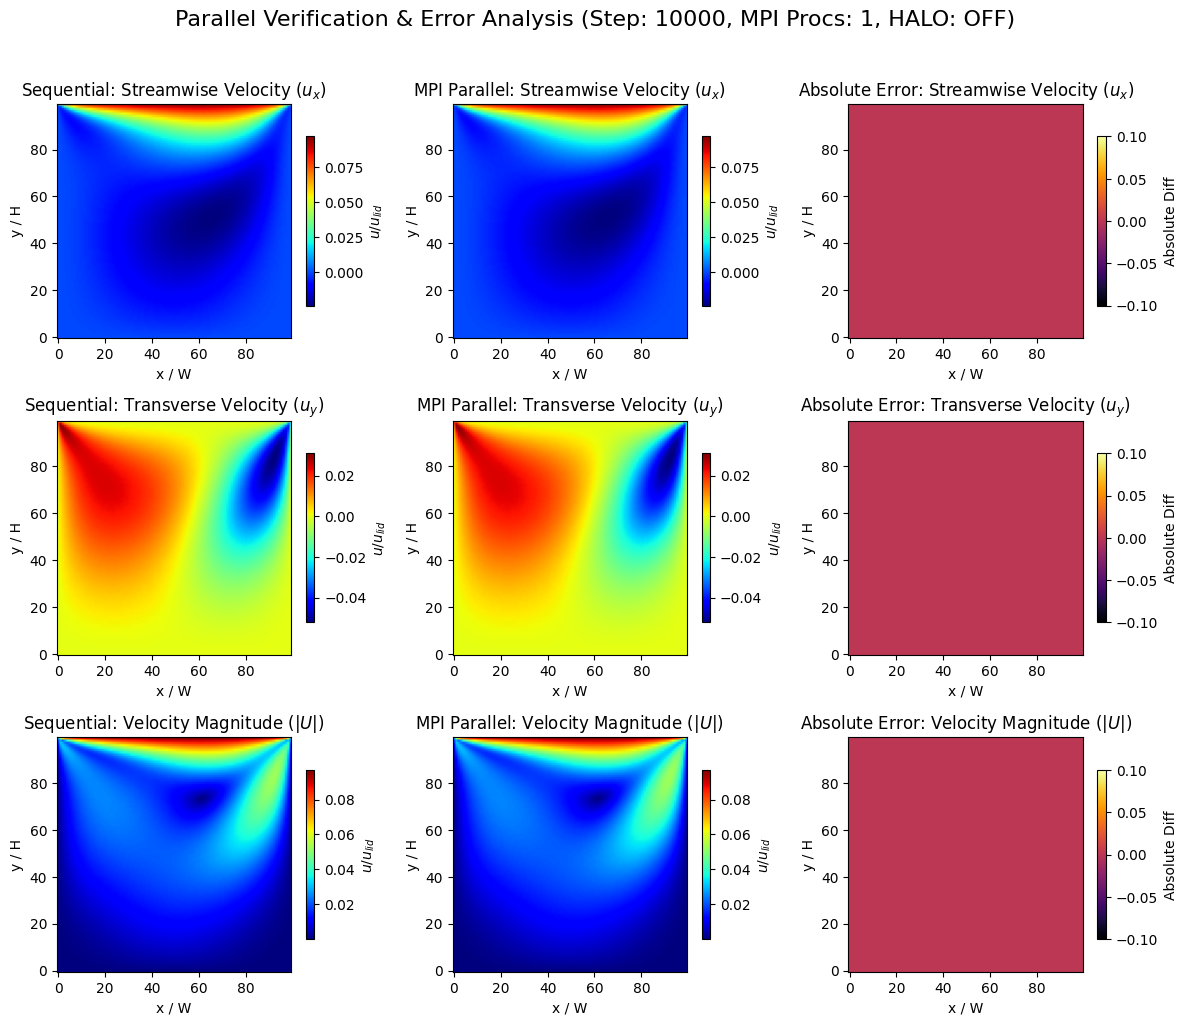

In [111]:
plot_parallel_verification_errors("_mpi_1_halo_off")

### 2.2 Decomposition WITHOUT HALO: We treat MPI boundaries as physical walls

Comparing: ../outputs/100x100/output_100x100_mpi_1_halo_on.csv VS ../outputs/100x100/output_100x100_mpi_2_halo_off.csv


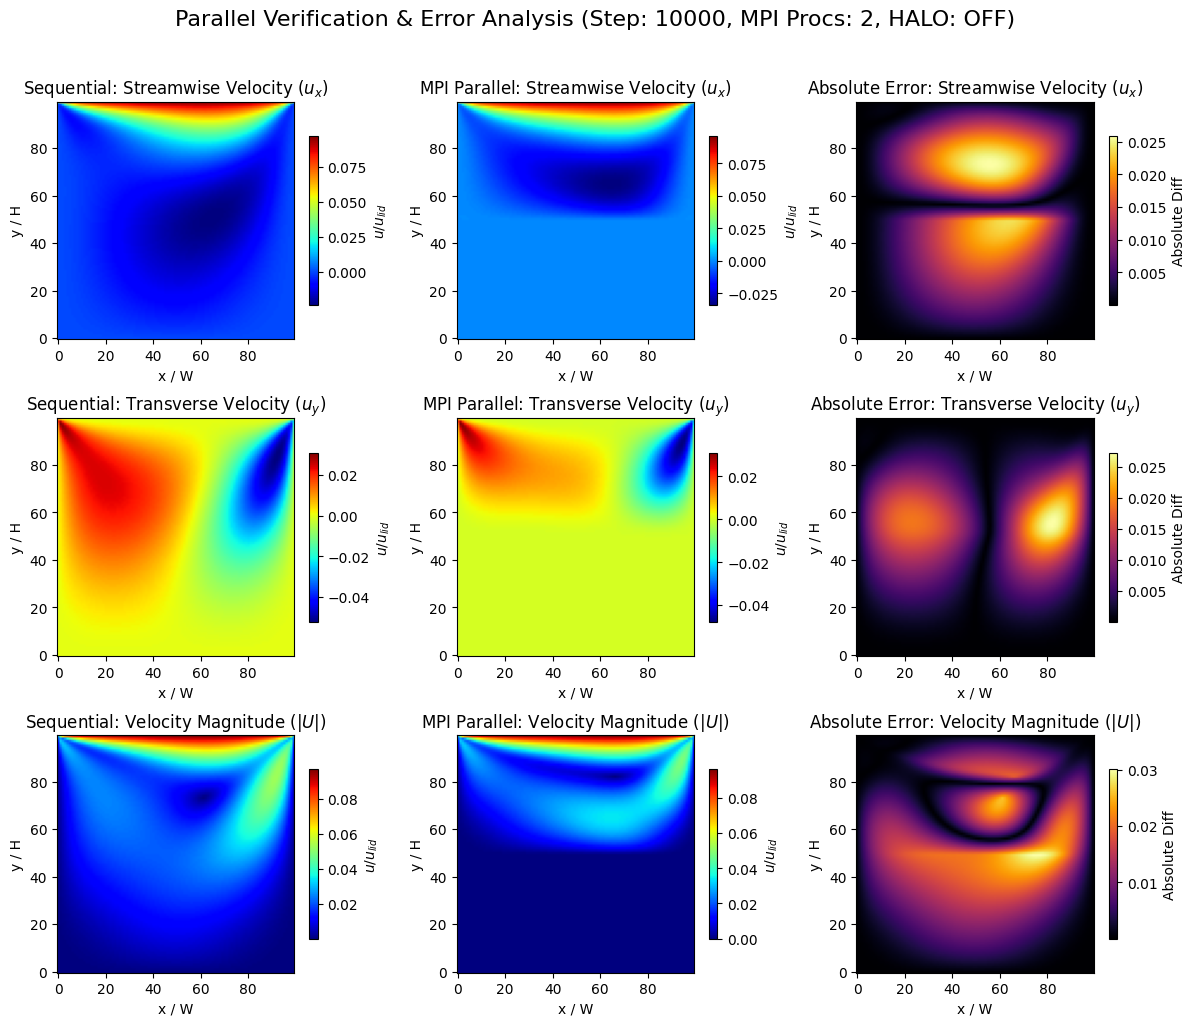

In [112]:
plot_parallel_verification_errors("_mpi_2_halo_off")

Comparing: ../outputs/100x100/output_100x100_mpi_1_halo_on.csv VS ../outputs/100x100/output_100x100_mpi_4_halo_off.csv


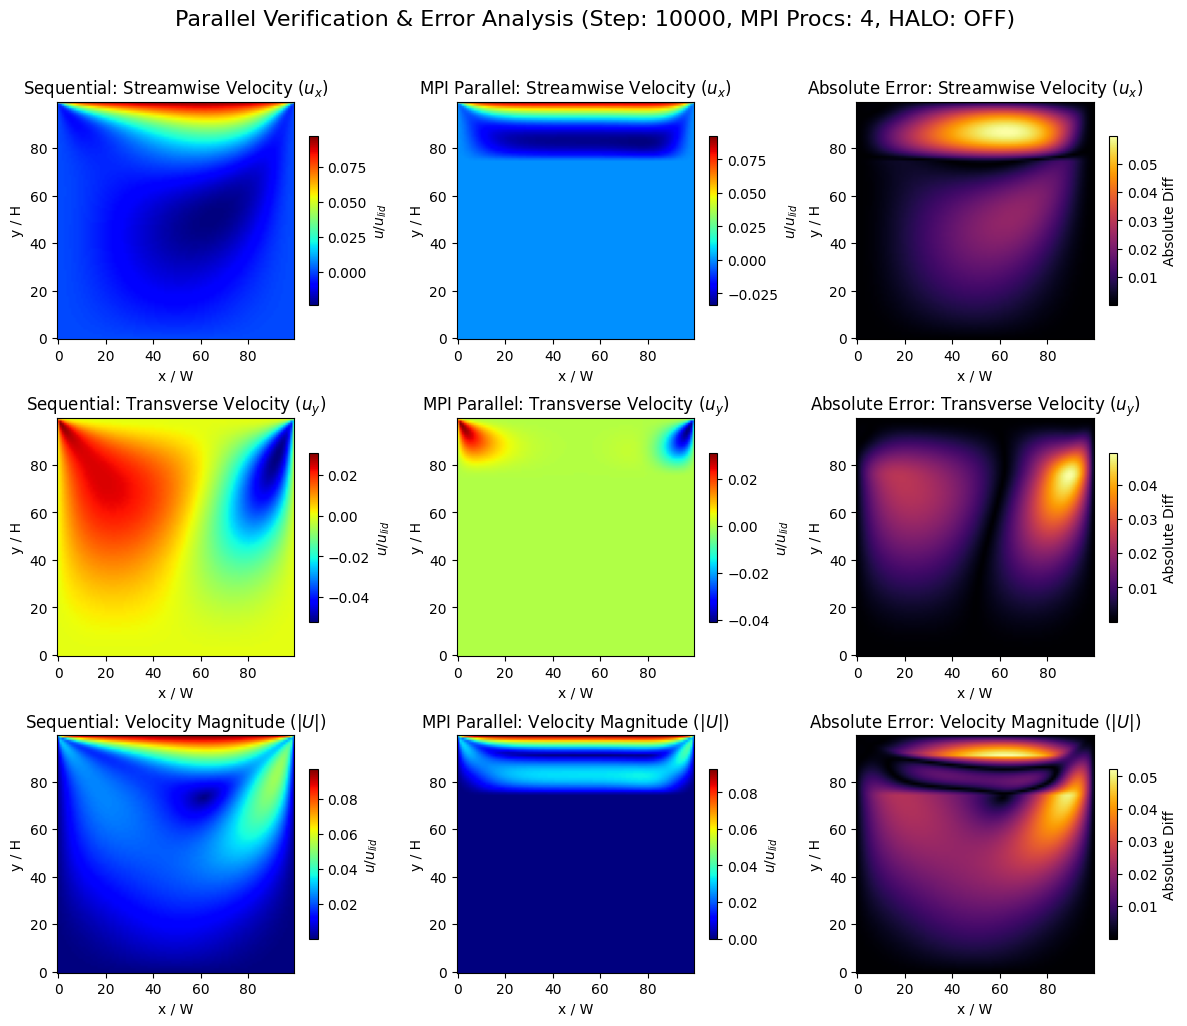

In [113]:
plot_parallel_verification_errors("_mpi_4_halo_off")

### 2.3 Decomposition WITH HALO

Comparing: ../outputs/100x100/output_100x100_mpi_1_halo_on.csv VS ../outputs/100x100/output_100x100_mpi_2_halo_on.csv


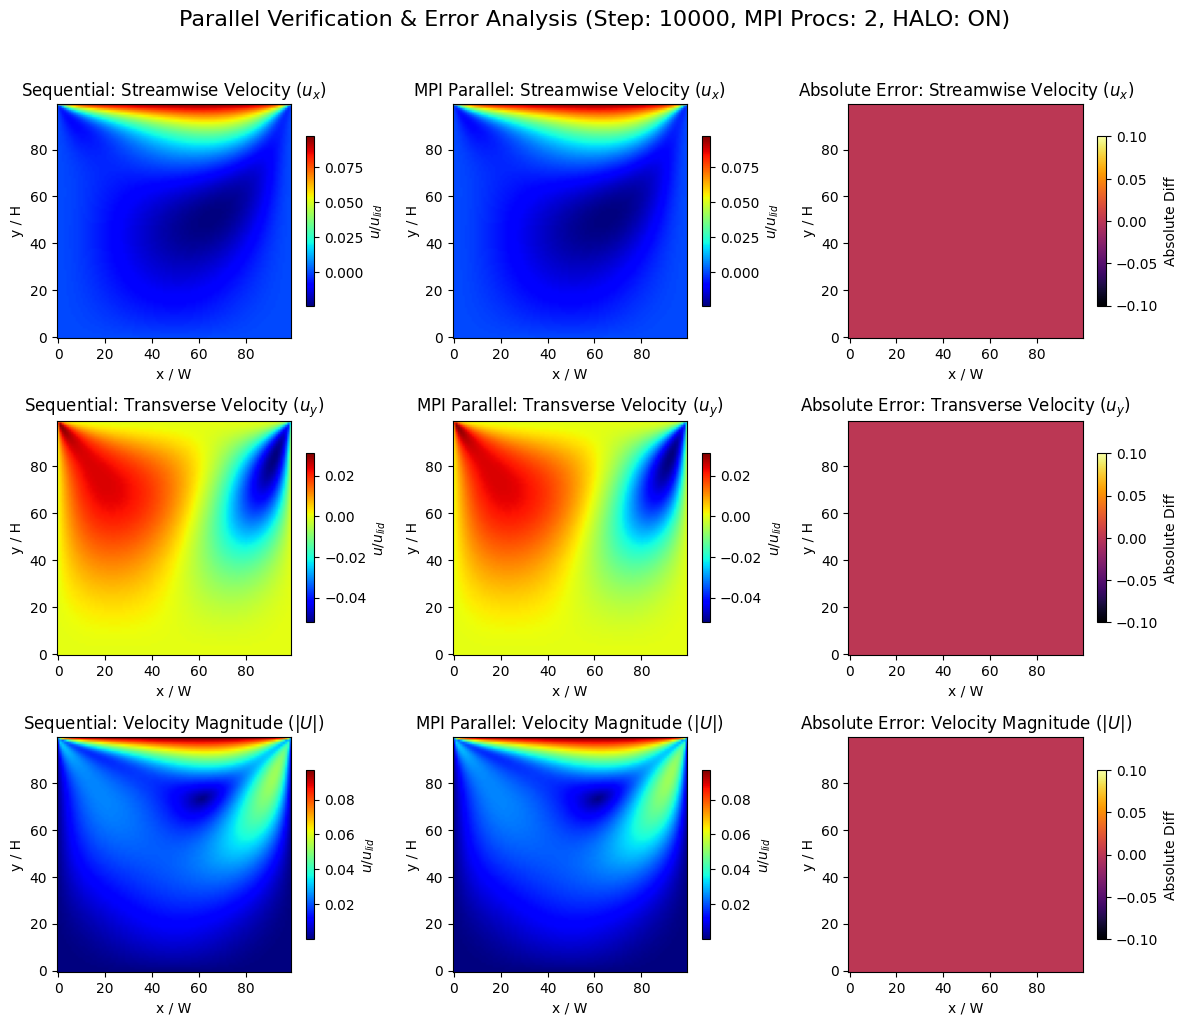

In [114]:
plot_parallel_verification_errors("_mpi_2_halo_on")

Comparing: ../outputs/100x100/output_100x100_mpi_1_halo_on.csv VS ../outputs/100x100/output_100x100_mpi_4_halo_on.csv


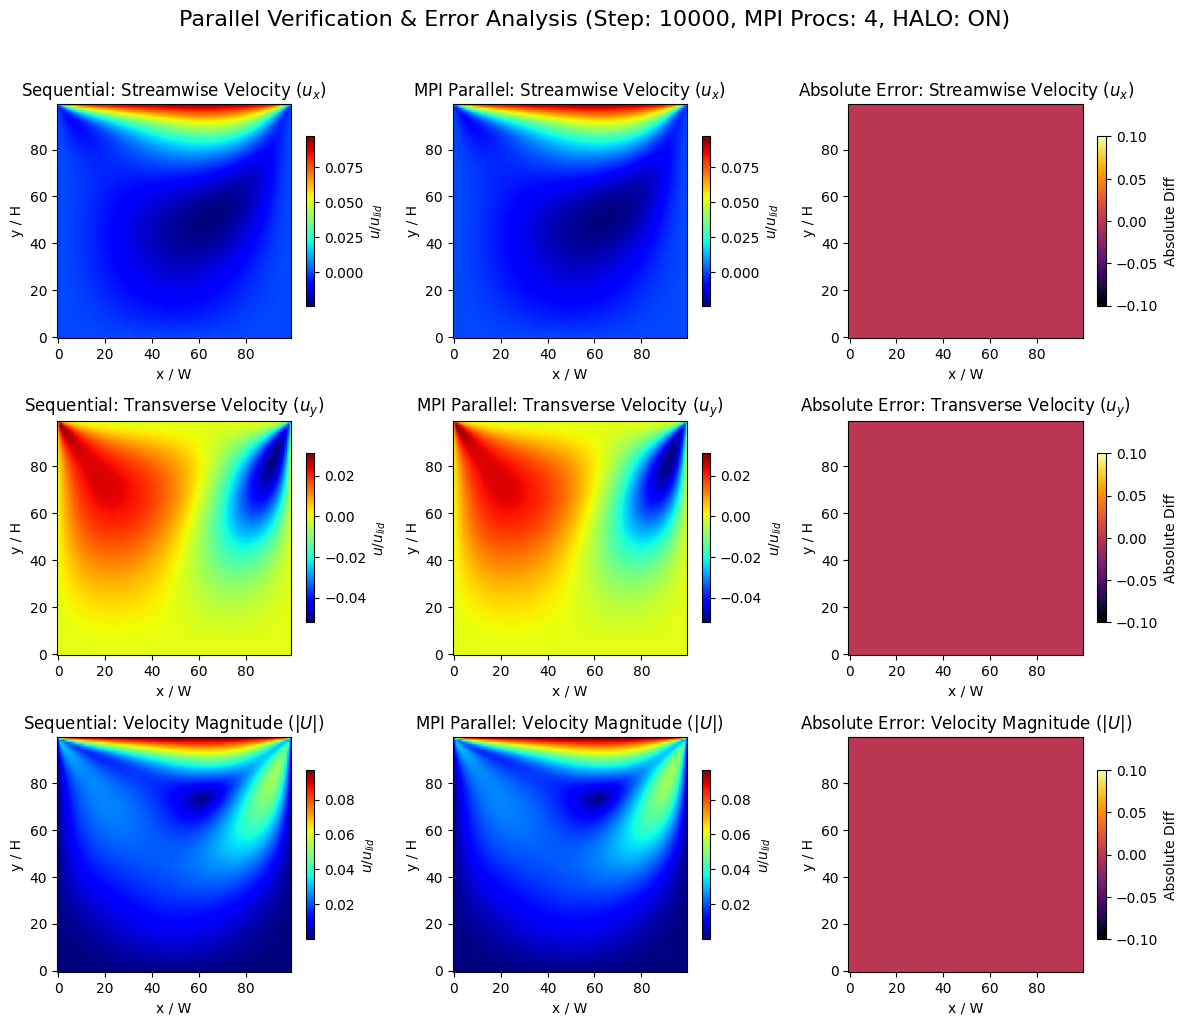

In [115]:
plot_parallel_verification_errors("_mpi_4_halo_on")

## 3. Benchmark: Scaling Performance

In [116]:
def get_benchmark():
    """
    Returns path to benchmark CSV for given grid size.
    """
    path = f"../outputs/{GRID}/benchmark_{GRID}.csv"
    if not os.path.exists(path):
        print(f"Error: Benchmark not found for grid={GRID}")
        return None
    
    return path

In [117]:
def plot_benchmark():
    bench_file = get_benchmark()

    if not bench_file:
        return

    # Load benchmark data from CSV file
    df = pd.read_csv(bench_file)

    # Compute average execution time for each MPI configuration
    df_avg = (
        df.groupby(["halo_mode", "nprocs"])["elapsed_time"]
        .mean()
        .reset_index()
    )

    # Compute speedup and efficiency separately for halo on/off
    for halo in df_avg["halo_mode"].unique():

        mask = df_avg["halo_mode"] == halo

        # Reference execution time for a single MPI process
        t1 = df_avg[
            (df_avg["halo_mode"] == halo) &
            (df_avg["nprocs"] == 1)
        ]["elapsed_time"].values[0]

        # Speedup = T1 / Tp
        df_avg.loc[mask, "speedup"] = (
            t1 / df_avg.loc[mask, "elapsed_time"]
        )

        # Parallel efficiency = Speedup / P
        df_avg.loc[mask, "efficiency"] = (
            df_avg.loc[mask, "speedup"]
            / df_avg.loc[mask, "nprocs"]
            * 100
        )

    # Create figure with three benchmark plots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

    # Plot results separately for halo on/off
    for halo in df_avg["halo_mode"].unique():

        data = df_avg[df_avg["halo_mode"] == halo]

        # Execution time
        ax1.plot(
            data["nprocs"],
            data["elapsed_time"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=f"Halo {halo}"
        )

        # Speedup
        ax2.plot(
            data["nprocs"],
            data["speedup"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=f"Halo {halo}"
        )

        # Parallel efficiency
        ax3.plot(
            data["nprocs"],
            data["efficiency"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=f"Halo {halo}"
        )

    # Execution time plot
    ax1.set_title("Elapsed time")
    ax1.set_xlabel("MPI processes")
    ax1.set_ylabel("Time [s]")
    ax1.set_xticks(sorted(df_avg["nprocs"].unique()))
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend()

    # Ideal speedup line
    nprocs_values = sorted(df_avg["nprocs"].unique())

    ax2.plot(
        nprocs_values,
        nprocs_values,
        "k--",
        linewidth=1,
        label="Ideal"
    )

    ax2.set_title("Speedup")
    ax2.set_xlabel("MPI processes")
    ax2.set_ylabel("Speedup")
    ax2.set_xticks(nprocs_values)
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend()

    # Ideal efficiency line
    ax3.axhline(
        y=100,
        color="k",
        linestyle="--",
        linewidth=1,
        label="Ideal"
    )

    ax3.set_title("Parallel efficiency")
    ax3.set_xlabel("MPI processes")
    ax3.set_ylabel("Efficiency [%]")
    ax3.set_xticks(nprocs_values)
    ax3.set_ylim([0, 140])
    ax3.grid(True, linestyle="--", alpha=0.5)
    ax3.legend()

    plt.suptitle(f"Benchmark — grid: {GRID}", fontsize=14)

    plt.tight_layout()
    plt.show()

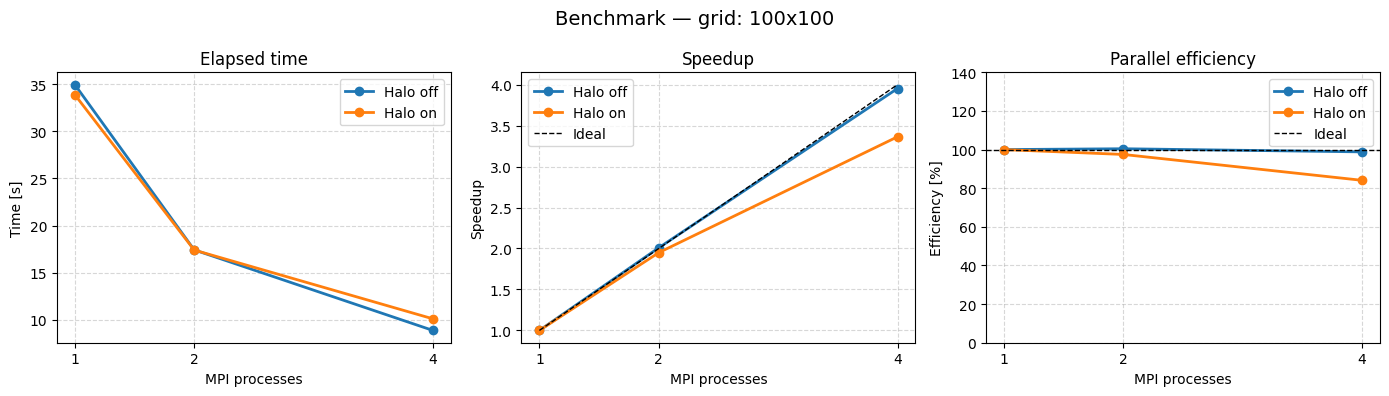

In [118]:
plot_benchmark()